# Demo 2 — Dirty Data, Clean Prediction

### Chapter 2 of the open tabular stack: *handles dirt*

> **Real data is messy. Tools should hide the mess.**
> *This is what Gaël's team has been building since dirty_cat.*

Three pipelines on the **employee salaries** dataset — strings, dates, divisions, job titles:

| Pipeline | What it represents |
|---|---|
| `HGBT manual` | Drop everything that isn't a number. The do-it-yourself baseline. |
| `TableVectorizer + HGBT` | Skrub recovers the columns you'd otherwise throw away. |
| `TableVectorizer + TabICL` | The same vectorizer, now feeding a foundation model. |

Skore decomposes the lift: how much comes from **preprocessing**, how much from the **model**.

---

**Stack used:**
- `skrub` — `TableVectorizer`, `fetch_employee_salaries`
- `scikit-learn` — `HistGradientBoostingRegressor`, train/test split
- `tabicl` — `TabICLRegressor`, the foundation model
- `skore` — `EstimatorReport` + `ComparisonReport` + Hub

In [1]:
import os
from pathlib import Path

# Load SKORE_HUB_API_KEY from .env at the repo root.
_repo_root = Path.cwd()
while not (_repo_root / ".env").exists() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
_env_path = _repo_root / ".env"
if _env_path.exists():
    for _line in _env_path.read_text().splitlines():
        _line = _line.strip()
        if _line and not _line.startswith("#") and "=" in _line:
            _k, _v = _line.split("=", 1)
            os.environ.setdefault(_k.strip(), _v.strip().strip('"'))

import skore
if "SKORE_HUB_API_KEY" in os.environ:
    skore.login()


╭───────────────────────────────── Login to Skore Hub ─────────────────────────────────╮
│                                                                                      │
│                        Successfully logged in, using API key.                        │
│                                                                                      │
╰──────────────────────────────────────────────────────────────────────────────────────╯

## 0. Setup

In [2]:
import time
import warnings
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

BLUE = "#1E22AA"
ORANGE = "#F68D2E"
GRAY = "#94A3B8"
DARK = "#1A1A2E"

@contextmanager
def stopwatch(label):
    t0 = time.perf_counter()
    yield (lambda: time.perf_counter() - t0)
    print(f"  [{label}] wall-clock: {time.perf_counter() - t0:.1f}s")

## 1. Employee salaries — strings, dates, divisions

Public Montgomery County salary data: ~9k rows of mixed-type messiness. Free-text
job titles, department codes, hire dates as strings, one lone numeric column.

We sub-sample to **2,000 rows** so the notebook stays under three minutes wall-clock
(TabICL inference is the floor).

In [3]:
from skrub.datasets import fetch_employee_salaries
from sklearn.model_selection import train_test_split

data = fetch_employee_salaries()
df = data.X.copy()
df["current_annual_salary"] = data.y
df = df.sample(n=2000, random_state=42).reset_index(drop=True)

X = df.drop(columns=["current_annual_salary"])
y = df["current_annual_salary"]

print(f"Shape: {X.shape}")
print(f"Dtypes: {X.dtypes.value_counts().to_dict()}")
print(f"Numeric columns only: {X.select_dtypes(include='number').columns.tolist()}")
display(X.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Shape: (2000, 8)
Dtypes: {<StringDtype(storage='python', na_value=nan)>: 7, dtype('int64'): 1}
Numeric columns only: ['year_first_hired']


,gender,department,department_name,division,assignment_category,employee_position_title,date_first_hired,year_first_hired
0,M,DLC,Department of Liquor Control,Clarksburg Village,Parttime-Regular,Liquor Store Clerk I,09/03/1991,1991
1,F,POL,Department of Police,FSB Traffic Division Automated Traffic Enforce...,Fulltime-Regular,Police Aide,02/05/2007,2007
2,F,COR,Correction and Rehabilitation,DS MCCF Case Managers Unit 1,Fulltime-Regular,Correctional Specialist IV,01/06/1997,1997
3,F,PRO,Office of Procurement,Procurement Director,Fulltime-Regular,Director Office of Procurement,01/28/2014,2014
4,M,HHS,Department of Health and Human Services,Income Supports,Fulltime-Regular,Income Assistance Program Specialist II,02/01/1999,1999


Train: (1600, 8), Test: (400, 8)


## 2. Three pipelines

1. **`HGBT manual`** — keep only `year_first_hired`. Everything else gets dropped
   because HGBT doesn't natively eat strings. This is the "I haven't met skrub yet" baseline.
2. **`TableVectorizer + HGBT`** — one line, all columns recovered.
3. **`TableVectorizer + TabICL`** — same vectorizer, foundation model on top.

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from skrub import TableVectorizer
from tabicl import TabICLRegressor

numeric_only = X.select_dtypes(include="number").columns.tolist()

manual_preproc = ColumnTransformer(
    [("keep_numeric", "passthrough", numeric_only)],
    remainder="drop",
)

pipelines = {
    "HGBT manual": make_pipeline(
        manual_preproc, HistGradientBoostingRegressor(random_state=42)
    ),
    "TableVectorizer + HGBT": make_pipeline(
        TableVectorizer(), HistGradientBoostingRegressor(random_state=42)
    ),
    "TableVectorizer + TabICL": make_pipeline(
        TableVectorizer(), TabICLRegressor(device="cpu", random_state=42)
    ),
}

fitted = {}
for name, pipe in pipelines.items():
    with stopwatch(name):
        pipe.fit(X_train, y_train)
        _ = pipe.predict(X_test[:5])
    fitted[name] = pipe

  [HGBT manual] wall-clock: 0.6s
  [TableVectorizer + HGBT] wall-clock: 0.7s
  [TableVectorizer + TabICL] wall-clock: 18.5s


## 3. Skore — one comparison, three models

Each fitted pipeline becomes an `EstimatorReport`. The `ComparisonReport` then
renders the metrics table and the prediction-error scatter side-by-side.

In [5]:
import skore

reports = {
    name: skore.EstimatorReport(
        est, fit=False,
        X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test,
    )
    for name, est in fitted.items()
}

comparison = skore.ComparisonReport(reports=reports)
metrics_df = comparison.metrics.summarize().frame()
metrics_df

Output()

Estimator,HGBT manual,TableVectorizer + HGBT,TableVectorizer + TabICL
Metric,,,
R²,0.190943,0.882492,0.915897
RMSE,23758.597106,9054.509670,7660.137360
Fit time (s),NaN,NaN,NaN
Predict time (s),0.010016,0.056033,21.444575


In [6]:
comparison.metrics.prediction_error()

Output()

## 4. The chart — R² across the three pipelines

Gray = numeric-only. Blue = skrub recovers the columns. Orange = skrub feeds TabICL.

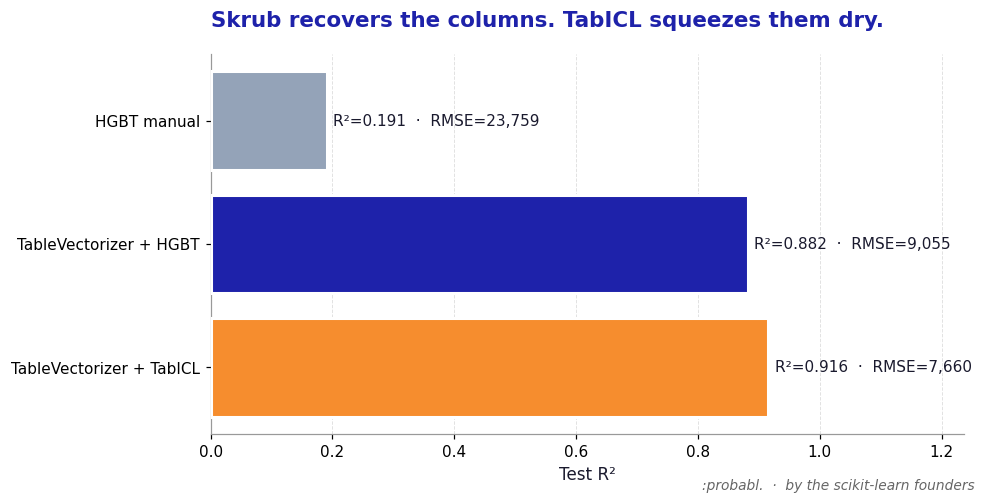

,step,from,to,delta R²
0,lift from preprocessing (HGBT only),0.191,0.882,+0.692
1,lift from model (with TableVectorizer),0.882,0.916,+0.033


In [7]:
from sklearn.metrics import r2_score, root_mean_squared_error

results = {}
for name, est in fitted.items():
    y_pred = est.predict(X_test)
    results[name] = {
        "r2": r2_score(y_test, y_pred),
        "rmse": root_mean_squared_error(y_test, y_pred),
    }

colors = {
    "HGBT manual": GRAY,
    "TableVectorizer + HGBT": BLUE,
    "TableVectorizer + TabICL": ORANGE,
}

names = list(results.keys())
r2s = [results[n]["r2"] for n in names]
bar_colors = [colors[n] for n in names]

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(names, r2s, color=bar_colors, edgecolor="white", linewidth=2, zorder=3)
for bar, n in zip(bars, names):
    w = bar.get_width()
    ax.text(
        w + 0.01, bar.get_y() + bar.get_height() / 2,
        f"R²={results[n]['r2']:.3f}  ·  RMSE={results[n]['rmse']:,.0f}",
        va="center", ha="left", fontsize=10, color=DARK,
    )

ax.set_xlim(0, max(r2s) * 1.35)
ax.invert_yaxis()
ax.set_xlabel("Test R²", color=DARK, fontsize=11)
ax.set_title(
    "Skrub recovers the columns. TabICL squeezes them dry.",
    color=BLUE, fontsize=14, fontweight="bold", loc="left", pad=18,
)
ax.grid(True, axis="x", color="#E0E0E0", linestyle="--", linewidth=0.6, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax.spines[spine].set_color("#999999")

fig.text(
    0.99, 0.02, ":probabl.  ·  by the scikit-learn founders",
    ha="right", color="#666666", fontsize=9, style="italic",
)

plt.tight_layout()
import os
os.makedirs("../recordings/final", exist_ok=True)
plt.savefig("../recordings/final/demo2_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

lift_preproc = results["TableVectorizer + HGBT"]["r2"] - results["HGBT manual"]["r2"]
lift_model = results["TableVectorizer + TabICL"]["r2"] - results["TableVectorizer + HGBT"]["r2"]
decomp = pd.DataFrame(
    [
        {
            "step": "lift from preprocessing (HGBT only)",
            "from": f"{results['HGBT manual']['r2']:.3f}",
            "to": f"{results['TableVectorizer + HGBT']['r2']:.3f}",
            "delta R²": f"+{lift_preproc:.3f}",
        },
        {
            "step": "lift from model (with TableVectorizer)",
            "from": f"{results['TableVectorizer + HGBT']['r2']:.3f}",
            "to": f"{results['TableVectorizer + TabICL']['r2']:.3f}",
            "delta R²": f"{lift_model:+.3f}",
        },
    ]
)
decomp

## 5. Push to Skore Hub

The comparison object is the artifact. One `put` and the URL is shareable.

In [ ]:
project = skore.Project("debray.yann/demo2-dirty-data", mode="hub")
for name, rep in reports.items():
    project.put(name, rep)
print(project)
print(f"https://skore.probabl.ai/{project.name}")


Output()